In [11]:
import pandas as pd
import numpy as np
from pathlib import Path

# ==============================
# 0) Base paths
# ==============================
BASE = Path.cwd()
BASE_UPLOAD = BASE / "DA_LMPs_Data" / "MISO"

# ==============================
# 1) Define ISO-NE DA file paths
# ==============================
zone_files = {
    "MINN.HUB":        BASE_UPLOAD / "df_DA_MISO_MINN.HUB_2025_DA_hourly.csv",
}

# If True, uses mean(|P[i+1]-P[i]|) inside each 6h block
USE_ABS_DIFF = True

# ==============================
# 2) Helpers: find time + price columns robustly
# ==============================
def pick_time_col(df: pd.DataFrame) -> str:
    preferred = [
        "interval_start_utc", "interval_start", "time", "timestamp", "datetime",
        "Interval Start", "IntervalStart", "interval_start_time_utc", "IntervalStartUTC"
    ]
    for c in preferred:
        if c in df.columns:
            return c
    best = None
    best_ok = -1
    for c in df.columns:
        s = pd.to_datetime(df[c], errors="coerce", utc=True)
        ok = int(s.notna().sum())
        if ok > best_ok:
            best_ok = ok
            best = c
    if best is None or best_ok == 0:
        raise ValueError(f"No datetime-like column found. Columns: {list(df.columns)}")
    return best

def pick_price_col(df: pd.DataFrame) -> str:
    candidates = ["lmp", "LMP", "price", "Price", "da_lmp", "DA_LMP", "lbmp", "LBMP", "value", "Value"]
    for c in candidates:
        if c in df.columns:
            return c
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if not num_cols:
        for c in df.columns:
            s = pd.to_numeric(df[c], errors="coerce")
            if s.notna().any():
                return c
        raise ValueError(f"No numeric price-like column found. Columns: {list(df.columns)}")
    return num_cols[0]

# ==============================
# 3) Compute 6-hour stats per zone
#    (mean price, cov, avg hourly diff, price spread)
# ==============================
zone_6h_avg_dict = {}
zone_6h_cov_dict = {}
zone_6h_avgdiff_dict = {}
zone_6h_spread_dict = {}

def compute_6h_avg_hourly_diff(hourly_series: pd.Series) -> pd.Series:
    """
    For each 6-hour block, compute mean(P[i+1]-P[i]) over the 5 hour-to-hour steps.
    """
    def _block_fn(block: pd.Series):
        block = block.dropna()
        if len(block) < 2:
            return np.nan
        diffs = block.diff().dropna()
        if USE_ABS_DIFF:
            diffs = diffs.abs()
        return float(diffs.mean())

    return hourly_series.resample("6h").apply(_block_fn)

def compute_6h_price_spread(hourly_series: pd.Series) -> pd.Series:
    """
    For each 6-hour block, compute max(P) - min(P).
    """
    def _block_fn(block: pd.Series):
        block = block.dropna()
        if len(block) == 0:
            return np.nan
        return float(block.max() - block.min())

    return hourly_series.resample("6h").apply(_block_fn)

for zone, file_path in zone_files.items():
    if not file_path.exists():
        raise FileNotFoundError(f"Missing file for {zone}: {file_path}")

    df = pd.read_csv(file_path)

    time_col = pick_time_col(df)
    price_col = pick_price_col(df)

    df[time_col] = pd.to_datetime(df[time_col], errors="coerce", utc=True)
    df[price_col] = pd.to_numeric(df[price_col], errors="coerce")

    df = df.dropna(subset=[time_col, price_col]).sort_values(time_col).set_index(time_col)

    # If duplicate timestamps exist, collapse them
    if not df.index.is_unique:
        df = df.groupby(level=0).mean(numeric_only=True)

    # Hourly mean price first
    hourly_price = df[price_col].resample("h").mean()

    # ---- 6-hour mean and std for CoV ----
    df_6h = hourly_price.resample("6h").agg(["mean", "std"])
    df_6h = df_6h.rename(columns={"mean": "mean_price", "std": "std_price"})
    df_6h["cov"] = df_6h["std_price"] / df_6h["mean_price"].replace(0, np.nan)

    # ---- avg hourly diff inside each 6h block ----
    avgdiff_6h = compute_6h_avg_hourly_diff(hourly_price)

    # ---- price spread inside each 6h block ----
    spread_6h = compute_6h_price_spread(hourly_price)

    zone_6h_avg_dict[zone] = df_6h["mean_price"]
    zone_6h_cov_dict[zone] = df_6h["cov"]
    zone_6h_avgdiff_dict[zone] = avgdiff_6h
    zone_6h_spread_dict[zone] = spread_6h

# ==============================
# 4) Combine all zones into wide tables
# ==============================
zone_6h_avg_df = pd.DataFrame(zone_6h_avg_dict).sort_index()
zone_6h_cov_df = pd.DataFrame(zone_6h_cov_dict).sort_index()
zone_6h_avgdiff_df = pd.DataFrame(zone_6h_avgdiff_dict).sort_index()
zone_6h_spread_df = pd.DataFrame(zone_6h_spread_dict).sort_index()

# ==============================
# 5) ISO-wide 6-hour averages (across zones)
# ==============================
iso_avg_6h_price = zone_6h_avg_df.mean(axis=1, skipna=True)
iso_avg_6h_cov = zone_6h_cov_df.mean(axis=1, skipna=True)
iso_avg_6h_avgdiff = zone_6h_avgdiff_df.mean(axis=1, skipna=True)
iso_avg_6h_spread = zone_6h_spread_df.mean(axis=1, skipna=True)

# ==============================
# 6) Annual scalar summaries
# ==============================
print("===== RESULTS (MINN MISO, 2025) =====")
print("Annual mean of 6h mean price (across zones):", round(float(iso_avg_6h_price.mean()), 2))
print("Annual mean of 6h CoV (across zones):", round(float(iso_avg_6h_cov.mean()), 4))
print("Annual mean of 6h avg hourly diff (across zones):", round(float(iso_avg_6h_avgdiff.mean()), 4))
print("Annual mean of 6h price spread (across zones):", round(float(iso_avg_6h_spread.mean()), 4))
print("USE_ABS_DIFF =", USE_ABS_DIFF)

# ==============================
# 7) Save outputs
# ==============================
out_dir = BASE / "outputs_minn_miso_6h"
out_dir.mkdir(parents=True, exist_ok=True)

zone_6h_avg_df.to_csv(out_dir / "minn_miso_zone_6h_mean_price.csv")
zone_6h_cov_df.to_csv(out_dir / "minn_miso_zone_6h_cov.csv")
zone_6h_avgdiff_df.to_csv(out_dir / "minn_miso_zone_6h_avg_hourly_price_diff.csv")
zone_6h_spread_df.to_csv(out_dir / "minn_miso_zone_6h_price_spread.csv")

iso_summary = pd.DataFrame({
    "iso_avg_6h_price": iso_avg_6h_price,
    "iso_avg_6h_cov": iso_avg_6h_cov,
    "iso_avg_6h_avg_hourly_price_diff": iso_avg_6h_avgdiff,
    "iso_avg_6h_price_spread": iso_avg_6h_spread,
})

# if duplicates somehow exist in the 6h index, collapse them
if not iso_summary.index.is_unique:
    iso_summary = iso_summary.groupby(level=0).mean()

iso_summary.to_csv(out_dir / "minn_miso_isoavg_6h_price_cov_avgdiff_spread.csv")

print(f"\nSaved outputs to: {out_dir}")
print("ISO-wide file:", out_dir / "minn_miso_isoavg_6h_price_cov_avgdiff_spread.csv")

===== RESULTS (MINN MISO, 2025) =====
Annual mean of 6h mean price (across zones): 41.19
Annual mean of 6h CoV (across zones): 0.237
Annual mean of 6h avg hourly diff (across zones): 5.7371
Annual mean of 6h price spread (across zones): 26.1601
USE_ABS_DIFF = True

Saved outputs to: C:\Users\hsofi\EVC\evc_project\bidding_strategy\outputs_minn_miso_6h
ISO-wide file: C:\Users\hsofi\EVC\evc_project\bidding_strategy\outputs_minn_miso_6h\minn_miso_isoavg_6h_price_cov_avgdiff_spread.csv


Processing MINN


C:\Users\hsofi\AppData\Local\Temp\ipykernel_28664\3217077187.py:49: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  rt_hourly = df_rt[rt_price].resample("H").mean()


Saved: C:\Users\hsofi\EVC\evc_project\bidding_strategy\outputs_minn_miso_dart\MINN_MISO_DART_EV_window_hourly.csv
Saved: C:\Users\hsofi\EVC\evc_project\bidding_strategy\outputs_minn_miso_dart\MINN_MISO_DART_daily_EV_window_mean.csv


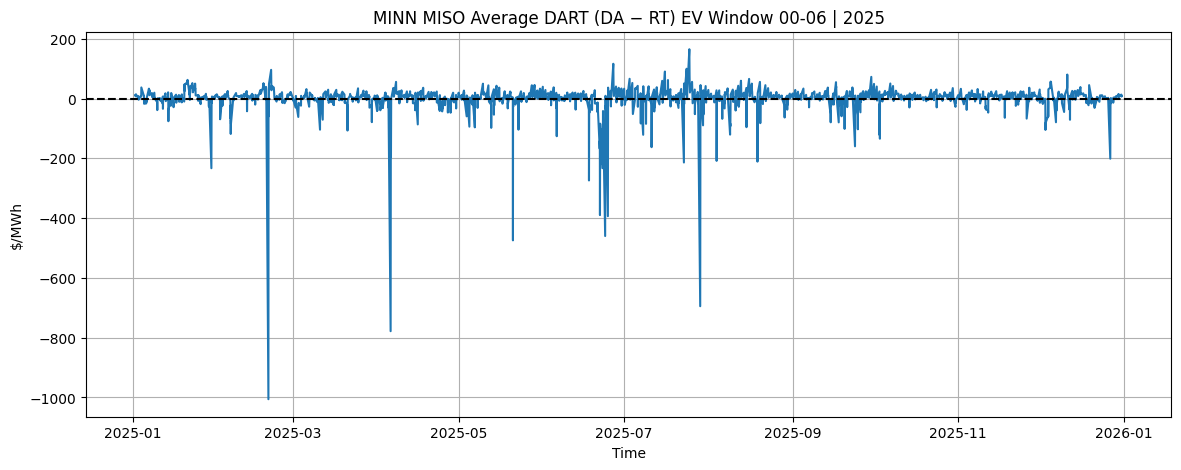

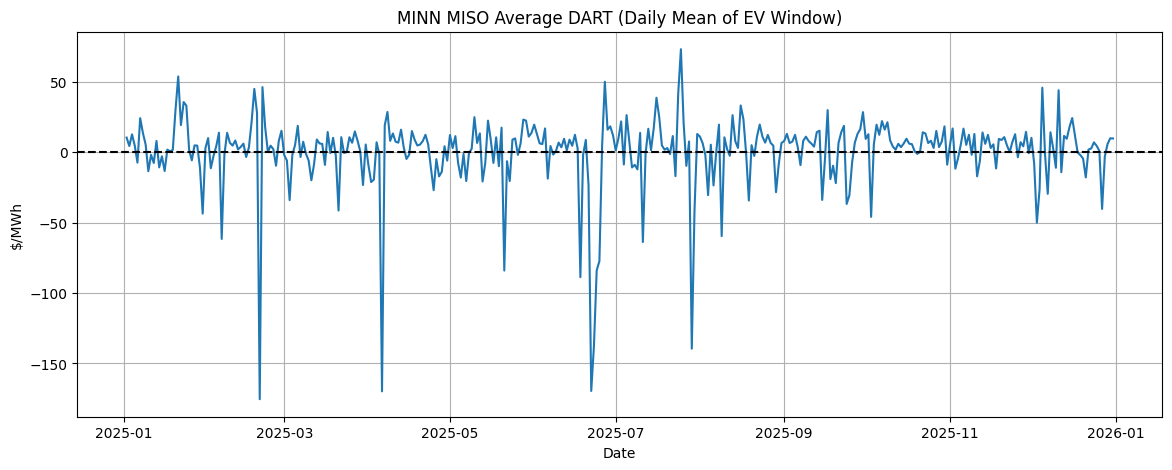

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path.cwd()

def p(*parts):
    return BASE.joinpath(*parts)

# ---------------------------------------------------------
# ISO-NE zones
# ---------------------------------------------------------

MINN_MISO_ZONES = [
"MINN",
]

START_HOUR = 0
END_HOUR = 6

series_by_zone = {}

for zone in MINN_MISO_ZONES:

    da_file = p("DA_LMPs_Data","MISO",f"df_DA_MISO_{zone}.HUB_2025_DA_hourly.csv")
    rt_file = p("RT_LMPs_Data","MISO",f"df_RT_MISO_{zone}.HUB_2025_RT_5min.csv")

    print("Processing", zone)

    df_da = pd.read_csv(da_file)
    df_rt = pd.read_csv(rt_file)

    # detect time column
    da_time = [c for c in df_da.columns if "time" in c.lower() or "interval" in c.lower()][0]
    rt_time = [c for c in df_rt.columns if "time" in c.lower() or "interval" in c.lower()][0]

    # detect price column
    da_price = [c for c in df_da.columns if "lmp" in c.lower() or "price" in c.lower()][0]
    rt_price = [c for c in df_rt.columns if "lmp" in c.lower() or "price" in c.lower()][0]

    df_da[da_time] = pd.to_datetime(df_da[da_time], utc=True)
    df_rt[rt_time] = pd.to_datetime(df_rt[rt_time], utc=True)

    df_da = df_da.set_index(da_time)
    df_rt = df_rt.set_index(rt_time)

    # convert RT 5-min to hourly
    rt_hourly = df_rt[rt_price].resample("H").mean()

    # align with DA
    merged = pd.concat([
        df_da[da_price].rename("DA"),
        rt_hourly.rename("RT")
    ],axis=1).dropna()

    merged["DART"] = merged["DA"] - merged["RT"]

    # EV charging window
    ev_window = merged[(merged.index.hour >= START_HOUR) & (merged.index.hour < END_HOUR)]

    series_by_zone[zone] = ev_window["DART"]

# ---------------------------------------------------------
# Combine zones
# ---------------------------------------------------------

iso_ne_dart_df = pd.concat(series_by_zone, axis=1)

iso_ne_dart_df["MINN_MISO_avg_DART"] = iso_ne_dart_df.mean(axis=1)

# ---------------------------------------------------------
# Save CSV
# ---------------------------------------------------------

out_dir = BASE / "outputs_minn_miso_dart"
out_dir.mkdir(exist_ok=True)

csv_path = out_dir / "MINN_MISO_DART_EV_window_hourly.csv"

iso_ne_dart_df.to_csv(csv_path)

print("Saved:", csv_path)

# ---------------------------------------------------------
# Daily aggregation (useful for clustering later)
# ---------------------------------------------------------

daily_dart = iso_ne_dart_df["MINN_MISO_avg_DART"].resample("D").mean()

daily_csv = out_dir / "MINN_MISO_DART_daily_EV_window_mean.csv"
daily_dart.to_csv(daily_csv)

print("Saved:", daily_csv)

# ---------------------------------------------------------
# Plot hourly
# ---------------------------------------------------------

plt.figure(figsize=(14,5))
plt.plot(iso_ne_dart_df.index, iso_ne_dart_df["MINN_MISO_avg_DART"])
plt.axhline(0,color="black",linestyle="--")
plt.title("MINN MISO Average DART (DA − RT) EV Window 00-06 | 2025")
plt.xlabel("Time")
plt.ylabel("$/MWh")
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# Plot daily
# ---------------------------------------------------------

plt.figure(figsize=(14,5))
plt.plot(daily_dart.index, daily_dart.values)
plt.axhline(0,color="black",linestyle="--")
plt.title("MINN MISO Average DART (Daily Mean of EV Window)")
plt.xlabel("Date")
plt.ylabel("$/MWh")
plt.grid(True)
plt.show()

In [13]:
# =========================================================
# ISO-NE (2025) Hourly DART (UTC) for ALL HOURS + Zone-Average
# Then 6-hour averaging of the HOURLY zone-average DART (UTC)
#
# Output (UTC timestamps):
#  1) outputs_iso_ne_dart/ISO_NE_hourly_DART_by_zone_UTC.csv
#  2) outputs_iso_ne_dart/ISO_NE_hourly_DART_ZONE_AVG_UTC.csv
#  3) outputs_iso_ne_dart/ISO_NE_6H_DART_ZONE_AVG_UTC.csv
# =========================================================

import numpy as np
import pandas as pd
from pathlib import Path

# ----------------------------
# 0) Settings
# ----------------------------
BASE = Path.cwd()

TZ_OUT = "UTC"                  # keep UTC
PRICE_COL_PREFERRED = "lmp"      # detect robustly if different
CLIP_LOW, CLIP_HIGH = -1000, 1000
RT_HOURLY_METHOD = "mean"        # mean/median/last


# ----------------------------
# 1) Robust I/O helpers
# ----------------------------
def p(*parts) -> str:
    return str(BASE.joinpath(*parts))

def load_table(path: str) -> pd.DataFrame:
    """Load CSV / XLS / XLSX, handles 'CSV text saved as .xls'."""
    fp = Path(path)
    if not fp.exists():
        raise FileNotFoundError(f"File not found:\n{fp}\n\nBASE={BASE}")

    pth = path.lower()

    # sniff for csv-like content even if extension is .xls
    head = fp.read_bytes()[:2048]
    try:
        txt = head.decode("utf-8", errors="strict")
        if ("," in txt and "\n" in txt) or ("\t" in txt and "\n" in txt) or (";" in txt and "\n" in txt):
            delim_counts = {",": txt.count(","), "\t": txt.count("\t"), ";": txt.count(";")}
            sep = max(delim_counts, key=delim_counts.get)
            return pd.read_csv(path, sep=sep, low_memory=False)
    except Exception:
        pass

    if pth.endswith(".csv"):
        return pd.read_csv(path, low_memory=False)

    if pth.endswith((".xls", ".xlsx")):
        for engine in ["openpyxl", "xlrd"]:
            try:
                return pd.read_excel(path, engine=engine)
            except Exception:
                pass
        try:
            tables = pd.read_html(path)
            if tables:
                return tables[0]
        except Exception:
            pass
        raise ValueError(f"Excel file format cannot be determined for: {path}")

    raise ValueError(f"Unsupported file type: {path}")


def _get_time_col(df: pd.DataFrame) -> str:
    for c in [
        "interval_start_utc", "interval_start", "time", "timestamp", "datetime",
        "Interval Start", "IntervalStart", "interval_start_time_utc", "IntervalStartUTC"
    ]:
        if c in df.columns:
            return c

    # fallback: most parseable column as datetime
    best = None
    best_ok = -1
    for c in df.columns:
        s = pd.to_datetime(df[c], errors="coerce", utc=True)
        ok = int(s.notna().sum())
        if ok > best_ok:
            best_ok = ok
            best = c
    if best is None or best_ok == 0:
        raise ValueError("No datetime column found. Columns:\n" + ", ".join(map(str, df.columns)))
    return best


def _pick_price_col(df: pd.DataFrame, preferred: str = "lmp") -> str:
    if preferred in df.columns:
        return preferred

    lower_map = {str(c).lower(): c for c in df.columns}
    if preferred.lower() in lower_map:
        return lower_map[preferred.lower()]

    candidates = [
        "lmp", "price", "da_lmp", "rt_lmp",
        "lbmp", "value",
        "settlement_point_price", "settlement_point_price_dollar_per_mwh",
        "market_price"
    ]
    for c in candidates:
        if c in df.columns:
            return c
        if c.lower() in lower_map:
            return lower_map[c.lower()]

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_cols:
        return numeric_cols[0]

    for c in df.columns:
        s = pd.to_numeric(df[c], errors="coerce")
        if s.notna().any():
            return c

    raise KeyError(f"Could not find a price column. Columns are:\n{list(df.columns)}")


def _to_utc_datetime(series: pd.Series) -> pd.Series:
    """
    Parse to tz-aware UTC timestamps robustly:
    - If already tz-aware: convert to UTC
    - If naive: assume it's UTC (common for *_utc columns)
    """
    s = pd.to_datetime(series, errors="coerce")
    try:
        # tz-aware?
        if getattr(s.dt, "tz", None) is not None:
            return s.dt.tz_convert("UTC")
    except Exception:
        pass
    # naive -> localize as UTC
    return s.dt.tz_localize("UTC")


# ----------------------------
# 2) DART hourly for one zone (ALL HOURS, UTC)
# ----------------------------
def compute_dart_hourly_all_hours_utc(
    df_rt: pd.DataFrame,
    df_da: pd.DataFrame,
    price_col_preferred: str = "lmp",
    clip_low: float = -1000,
    clip_high: float = 1000,
    rt_hourly_method: str = "mean",
) -> pd.DataFrame:

    rt_time = _get_time_col(df_rt)
    da_time = _get_time_col(df_da)
    rt_price = _pick_price_col(df_rt, price_col_preferred)
    da_price = _pick_price_col(df_da, price_col_preferred)

    # ---- RT (5-min) -> HOURLY UTC ----
    rt = df_rt[[rt_time, rt_price]].copy()
    rt[rt_time] = _to_utc_datetime(rt[rt_time])
    rt[rt_price] = pd.to_numeric(rt[rt_price], errors="coerce")
    rt = rt.dropna(subset=[rt_time, rt_price]).sort_values(rt_time)

    rt["price"] = rt[rt_price].clip(lower=clip_low, upper=clip_high)
    rt = rt.set_index(rt_time)[["price"]]

    if rt_hourly_method == "mean":
        rt_h = rt.resample("h").mean()
    elif rt_hourly_method == "median":
        rt_h = rt.resample("h").median()
    elif rt_hourly_method == "last":
        rt_h = rt.resample("h").last()
    else:
        raise ValueError("rt_hourly_method must be one of: mean, median, last")

    rt_h = rt_h.rename(columns={"price": "RT_hourly"})

    # ---- DA (already hourly) -> HOURLY UTC index ----
    da = df_da[[da_time, da_price]].copy()
    da[da_time] = _to_utc_datetime(da[da_time])
    da[da_price] = pd.to_numeric(da[da_price], errors="coerce")
    da = da.dropna(subset=[da_time, da_price]).sort_values(da_time)

    da["price"] = da[da_price].clip(lower=clip_low, upper=clip_high)
    da = da.set_index(da_time)[["price"]].rename(columns={"price": "DA_hourly"})

    da_h = da.resample("h").mean()

    # ---- merge + DART ----
    merged = da_h.join(rt_h, how="inner")
    merged["DART_DA_minus_RT"] = merged["DA_hourly"] - merged["RT_hourly"]

    # ensure UTC tz-aware index name
    merged.index = merged.index.tz_convert("UTC")
    merged.index.name = "ts_utc"
    return merged


# ----------------------------
# 3) ISO-NE zones (DA + RT)
# ----------------------------
MINN_MISO_ZONES = [
    "MINN",
]

MINN_MISO_CASES = [
    (
        zone,
        p("DA_LMPs_Data", "MISO", f"df_DA_MISO_{zone}.HUB_2025_DA_hourly.csv"),
        p("RT_LMPs_Data", "MISO", f"df_RT_MISO_{zone}.HUB_2025_RT_5min.csv"),
    )
    for zone in MINN_MISO_ZONES
]


# ----------------------------
# 4) Compute hourly DART per zone (UTC), then zone-average each UTC hour
# ----------------------------
dart_by_zone = {}

print("BASE =", BASE)
for zone, da_path, rt_path in MINN_MISO_CASES:
    print(f"\n--- MIDWEST MISO {zone} ---")
    print("DA:", da_path)
    print("RT:", rt_path)

    df_da = load_table(da_path)
    df_rt = load_table(rt_path)

    dart_hourly = compute_dart_hourly_all_hours_utc(
        df_rt=df_rt,
        df_da=df_da,
        price_col_preferred=PRICE_COL_PREFERRED,
        clip_low=CLIP_LOW,
        clip_high=CLIP_HIGH,
        rt_hourly_method=RT_HOURLY_METHOD,
    )

    s = dart_hourly["DART_DA_minus_RT"].rename(zone)
    dart_by_zone[zone] = s

# Align all zones on hourly UTC timestamps
iso_ne_hourly_df = pd.concat(dart_by_zone.values(), axis=1).sort_index()
iso_ne_hourly_df.index.name = "ts_utc"

# Hourly average across zones (for each hour timestamp, UTC)
iso_ne_hourly_df["MINN_MISO_ZONE_AVG_DART"] = iso_ne_hourly_df.mean(axis=1, skipna=True)

# ----------------------------
# 5) 6-hour averaging AFTER hourly zone-average (UTC bins)
# ----------------------------
iso_ne_6h_avg = (
    iso_ne_hourly_df[["MINN_MISO_ZONE_AVG_DART"]]
    .resample("6H")
    .mean()
    .rename(columns={"MINN_MISO_ZONE_AVG_DART": "MINN_MISO_6H_AVG_DART"})
)
iso_ne_6h_avg.index.name = "ts_utc"

# ----------------------------
# 6) Save outputs
# ----------------------------
out_dir = BASE / "outputs_minn_miso_dart"
out_dir.mkdir(parents=True, exist_ok=True)

path_zone_hourly = out_dir / "MINN_MISO_hourly_DART_by_zone_UTC.csv"
path_hourly_avg  = out_dir / "MINN_MISO_hourly_DART_ZONE_AVG_UTC.csv"
path_6h_avg      = out_dir / "MINN_MISO_6H_DART_ZONE_AVG_UTC.csv"

iso_ne_hourly_df.to_csv(path_zone_hourly)
iso_ne_hourly_df[["MINN_MISO_ZONE_AVG_DART"]].to_csv(path_hourly_avg)
iso_ne_6h_avg.to_csv(path_6h_avg)

print("\nSaved:")
print("1) Hourly DART by zone + hourly zone-average (UTC):", path_zone_hourly)
print("2) Hourly zone-average only (UTC):", path_hourly_avg)
print("3) 6-hour averaged from hourly zone-average (UTC):", path_6h_avg)

# ----------------------------
# 7) Quick summaries
# ----------------------------
print("\nHourly zone-average summary (UTC):")
print(iso_ne_hourly_df["MINN_MISO_ZONE_AVG_DART"].describe())

print("\n6-hour averaged summary (UTC):")
print(iso_ne_6h_avg["MINN_MISO_6H_AVG_DART"].describe())

BASE = C:\Users\hsofi\EVC\evc_project\bidding_strategy

--- MIDWEST MISO MINN ---
DA: C:\Users\hsofi\EVC\evc_project\bidding_strategy\DA_LMPs_Data\MISO\df_DA_MISO_MINN.HUB_2025_DA_hourly.csv
RT: C:\Users\hsofi\EVC\evc_project\bidding_strategy\RT_LMPs_Data\MISO\df_RT_MISO_MINN.HUB_2025_RT_5min.csv


C:\Users\hsofi\AppData\Local\Temp\ipykernel_28664\510692832.py:255: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("6H")



Saved:
1) Hourly DART by zone + hourly zone-average (UTC): C:\Users\hsofi\EVC\evc_project\bidding_strategy\outputs_minn_miso_dart\MINN_MISO_hourly_DART_by_zone_UTC.csv
2) Hourly zone-average only (UTC): C:\Users\hsofi\EVC\evc_project\bidding_strategy\outputs_minn_miso_dart\MINN_MISO_hourly_DART_ZONE_AVG_UTC.csv
3) 6-hour averaged from hourly zone-average (UTC): C:\Users\hsofi\EVC\evc_project\bidding_strategy\outputs_minn_miso_dart\MINN_MISO_6H_DART_ZONE_AVG_UTC.csv

Hourly zone-average summary (UTC):
count    8720.000000
mean        1.781732
std        31.440524
min      -565.127500
25%        -2.105625
50%         4.061250
75%        11.931667
max       207.064167
Name: MINN_MISO_ZONE_AVG_DART, dtype: float64

6-hour averaged summary (UTC):
count    1457.000000
mean        1.807630
std        19.522394
min      -164.684028
25%        -2.561086
50%         3.810139
75%        10.142879
max       119.883889
Name: MINN_MISO_6H_AVG_DART, dtype: float64
